# <font color='blue'>Tarea 2. </font>
### <font color='red'>15 de diciembre de 2025</font>
### Andrés Padrón Quintana 
### <font color='green'>Módulo 5. DATA SCIENCE AND MACHINE LEARNING APPLIED TO FINANCIAL MARKETS </font>

1. Encontrar una estructura de Red Diferente[ (sin cambiar el optimizador), sólo se puede cambiar número de capas, función de activación y/o número de neuronas] que tenga un mejor Accuracy Promedio que el visto en clase para los 5 folds (85-86) fuera de la muestra. 

Si quieren pueden combinar modelos antes de la Red Neuronal(métodos de ensamble por ejemplo). El objetivo es usar una red Neuronal como última instancia. 

Por ejemplo, pueden hacer un Stacking (SVM, Árbol, Logística, KNN, etc) y en el Meta Modelo usar un Red Neuronal. 

Se propone una arquitectura de red neuronal distinta a la vista en clase.
La red original (`define_model`) tiene la forma:

- `Flatten(input_shape=(28, 28, 1))`
- `Dense(350, activation="relu")`
- `Dense(100, activation="relu")`
- `Dense(10, activation="softmax")`

Necestiamos construir una red con:
- Mayor capacidad (más neuronas en las capas ocultas).
- Regularización vía Dropout para reducir el sobreajuste.
- Mantener el mismo optimizador (`SGD`) y la misma función de pérdida (`categorical_crossentropy`).

A continuación se define la función `define_model_tarea2()`, que construye el nuevo modelo.

In [12]:
# Imports básicos (igual que en el notebook original)

# Importamos librerías 
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

# Función cargar_datos

def cargar_datos():
    """
    Descarga el dataset Fashion-MNIST, le hace reshape para que quede con forma
    (n, 28, 28, 1) y aplica one-hot encoding a las etiquetas.
    Regresa: X_train, y_train, X_test, y_test
    """
    # 1) Descargar datos de Fashion-MNIST
    #    X_train, X_test: imágenes de 28 x 28 píxeles (uint8)
    #    y_train, y_test: etiquetas enteras (0–9)
    (X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
    
    # 2) Hacer reshape para agregar el canal (1) y que quede (n, 28, 28, 1)
    #    Esto es lo que Keras espera para capas convolucionales / imágenes.
    X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
    X_test  = X_test.reshape((X_test.shape[0], 28, 28, 1))
    
    # 3) One Hot Encoding de las etiquetas:
    #    Convertimos cada etiqueta entera en un vector de 10 posiciones
    #    (por ejemplo, clase 3 -> [0,0,0,1,0,0,0,0,0,0]).
    y_train = tf.keras.utils.to_categorical(y_train)
    y_test  = tf.keras.utils.to_categorical(y_test)
    
    # 4) Regresamos imágenes y etiquetas
    return X_train, y_train, X_test, y_test

# Función escalar_imagen (del notebook original)
def escalar_imagen(train, test):
    """
    Convierte las imágenes a float32 y las normaliza al rango [0,1]
    dividiendo entre el valor máximo de train.
    """
    # 1) Buscamos el valor máximo en el conjunto de entrenamiento
    maximo = train.max()
    
    # 2) Convertimos a float32 y dividimos por ese máximo
    train_norm = train.astype("float32") / maximo
    test_norm  = test.astype("float32") / maximo
    
    # 3) Regresamos las imágenes normalizadas
    return train_norm, test_norm


In [13]:
# Definimos el modelo general

def define_model():
    """
    Modelo original del notebook:
    Flatten -> Dense(350, relu) -> Dense(100, relu) -> Dense(10, softmax)
    """
    Xin = Input(shape=(28, 28, 1))             # capa de entrada (imagen 28x28x1)
    X = Flatten()(Xin)                         # aplanamos la imagen a un vector
    
    X = Dense(350, activation="relu")(X)       # primera capa oculta con 350 neuronas
    X = Dense(100, activation="relu")(X)       # segunda capa oculta con 100 neuronas
    
    X = Dense(10, activation="softmax")(X)     # capa de salida para 10 clases
    model = Model(inputs=Xin, outputs=X)
    
    opt = SGD(learning_rate=0.01)              # mismo optimizador del notebook
    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [7]:
# Modelo alternativo 

# Cargamos paquetes
from tensorflow.keras.layers import Dropout

def define_model_tarea2():
    """
    Esta función define una red neuronal alternativa para la Tarea 2.
    Mantiene el mismo tipo de entrada y salida que el modelo original,
    pero cambia la arquitectura interna (más neuronas y Dropout).
    """
    
    # 1) Definimos la capa de entrada con la misma forma que Fashion-MNIST
    #    Cada imagen es de 28 x 28 píxeles con 1 canal (escala de grises).
    Xin = Input(shape=(28, 28, 1))
    
    # 2) Aplanamos la imagen: de 28x28 pasamos a un vector de 784 componentes.
    #    Esto permite conectar la imagen a capas Dense.
    X = Flatten()(Xin)
    
    # 3) Primera capa oculta:
    #    - 512 neuronas (más que las 350 del modelo original).
    #    - Activación ReLU para introducir no linealidad.
    X = Dense(512, activation="relu")(X)
    
    # 4) Dropout:
    #    - Apaga aleatoriamente el 30% de las neuronas de esta capa en cada batch.
    #    - Ayuda a evitar sobreajuste (el modelo no "memoriza" tan fácil el train).
    X = Dropout(0.3)(X)
    
    # 5) Segunda capa oculta:
    #    - 256 neuronas (más que las 100 del modelo original).
    #    - También con activación ReLU.
    X = Dense(256, activation="relu")(X)
    
    # 6) Otro Dropout del 30%:
    #    - Más regularización.
    X = Dropout(0.3)(X)
    
    # 7) Capa de salida:
    #    - 10 neuronas, una por cada clase de Fashion-MNIST.
    #    - Activación softmax para obtener probabilidades por clase.
    X = Dense(10, activation="softmax")(X)
    
    # 8) Definimos el modelo final indicando entradas y salidas.
    model = Model(inputs=Xin, outputs=X)
    
    # 9) Definimos el optimizador.
    #    - Usamos el mismo SGD con learning rate = 0.01, como en el notebook.
    opt = SGD(learning_rate=0.01)
    
    # 10) Compilamos el modelo:
    #     - Pérdida: categorical_crossentropy (clasificación multiclase).
    #     - Métrica: accuracy.
    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    # 11) Regresamos el modelo ya compilado.
    return model


### Función de evaluación genérica con K-fold

En el notebook original se define una función `evaluar_modelo(dataX, dataY, n_folds=5)`
que siempre utiliza el modelo `define_model()`.

Para poder comparar fácilmente distintas arquitecturas (por ejemplo, el modelo original
y el modelo de la Tarea 2), conviene escribir una función de evaluación **genérica** que:

- Reciba como argumento la **función que construye el modelo** (`model_fn`),
  por ejemplo `define_model` o `define_model_tarea2`.
- Aplique validación cruzada K-fold sobre los datos de entrenamiento.
- Devuelva:
  - La lista de accuracies por fold.
  - La lista de historiales (histories) de entrenamiento, para graficar.

A continuación se define `evaluar_modelo_generico(model_fn, dataX, dataY, ...)`.


In [8]:
# ============================================
# Función genérica para evaluar cualquier modelo
# ============================================

from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt

def evaluar_modelo_generico(model_fn, dataX, dataY, n_folds=5, epochs=3, batch_size=30):
    """
    model_fn: función que construye y compila un modelo Keras.
              Ejemplos: define_model, define_model_tarea2, etc.
    dataX, dataY: datos de entrada y etiquetas (ya escalados y en one-hot).
    n_folds: número de folds de la validación cruzada.
    epochs: número de épocas de entrenamiento por fold.
    batch_size: tamaño de batch.
    """
    
    # 1) Listas donde vamos a guardar:
    #    - scores: accuracy por fold.
    #    - histories: historial de entrenamiento por fold (para graficar).
    scores = list()
    histories = list()
    
    # 2) Definimos el objeto de validación cruzada KFold.
    #    - shuffle=True para barajar los datos.
    #    - random_state fijo para reproducibilidad.
    kfold = KFold(n_splits=n_folds, shuffle=True, random_state=1)
    
    # 3) Recorremos cada fold.
    #    kfold.split(dataX) nos regresa los índices de train y de test para cada fold.
    for fold, (train_ix, test_ix) in enumerate(kfold.split(dataX), start=1):
        print(f"\n===== Fold {fold} de {n_folds} =====")
        
        # 4) Para cada fold, construimos un modelo NUEVO llamando a model_fn().
        #    Esto es importante: no reutilizamos pesos entre folds.
        model = model_fn()
        
        # 5) Seleccionamos las filas correspondientes al fold actual:
        #    - trainX/trainY: datos de entrenamiento del fold.
        #    - testX/testY:   datos de validación del fold.
        trainX, trainY = dataX[train_ix], dataY[train_ix]
        testX,  testY  = dataX[test_ix],  dataY[test_ix]
        
        # 6) Entrenamos el modelo:
        #    - epochs: número de pasadas completas sobre el conjunto de entrenamiento.
        #    - batch_size: tamaño de cada mini-lote.
        #    - validation_data: datos del fold para ir midiendo el desempeño fuera de muestra.
        #    - verbose=0: no imprime cada época (solo dejamos nuestros prints).
        history = model.fit(
            trainX, trainY,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(testX, testY),
            verbose=0
        )
        
        # 7) Evaluamos el modelo entrenado en el conjunto de validación del fold.
        #    model.evaluate regresa [loss, accuracy] (en este caso).
        loss, acc = model.evaluate(testX, testY, verbose=0)
        
        # 8) Imprimimos el accuracy del fold (en porcentaje).
        print(f"Accuracy fold: {acc * 100:.2f}%")
        
        # 9) Guardamos resultados en nuestras listas.
        scores.append(acc)
        histories.append(history)
    
    # 10) Al terminar todos los folds, calculamos promedio y desviación estándar.
    mean_acc = np.mean(scores)
    std_acc = np.std(scores)
    
    print("\n===== Resumen Validación Cruzada =====")
    print(f"Accuracy promedio: {mean_acc * 100:.2f}%")
    print(f"Desviación estándar: {std_acc * 100:.2f}%")
    
    # 11) Regresamos las listas completas para poder graficar o analizar después.
    return scores, histories


### Entrenamiento y comparación de modelos

En esta sección se:

1. Cargan los datos Fashion-MNIST con la función `cargar_datos()` ya definida en el notebook.
2. Se escalan las imágenes al rango `[0,1]` utilizando `escalar_imagen()`.
3. Se evalúan dos modelos distintos mediante validación cruzada de 5 folds:
   - El modelo original `define_model` visto en clase.
   - El modelo alternativo `define_model_tarea2` propuesto en la Tarea 2.
4. Se comparan los accuracies promedio y, opcionalmente, se grafican las curvas de entrenamiento
   usando la función `graficar_resumen(histories)`.


In [14]:
# Comparar modelo original vs modelo Tarea 2

# 1) Cargar los datos originales (Fashion-MNIST).
#    Esta función ya está definida en el notebook.
trainX, trainY, testX, testY = cargar_datos()

# 2) Escalar las imágenes al rango [0,1].
#    También es una función que ya viene en el notebook.
trainX, testX = escalar_imagen(trainX, testX)

# 3) Evaluar el modelo original de clase (define_model) con 5 folds.
print(">>> Modelo original (define_model)")
scores_base, histories_base = evaluar_modelo_generico(
    model_fn=define_model,   # función que construye el modelo original
    dataX=trainX,
    dataY=trainY,
    n_folds=5,
    epochs=3,                # mismo número de epochs que en el notebook
    batch_size=30
)

# 4) Evaluar el modelo alternativo de la Tarea 2.
print("\n\n>>> Modelo alternativo (define_model_tarea2)")
scores_t2, histories_t2 = evaluar_modelo_generico(
    model_fn=define_model_tarea2,  # función que construye el modelo nuevo
    dataX=trainX,
    dataY=trainY,
    n_folds=5,
    epochs=3,
    batch_size=30
)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
>>> Modelo original (define_model)

===== Fold 1 de 5 =====
Accuracy fold: 84.56%

===== Fold 2 de 5 =====
Accuracy fold: 85.23%

===== Fold 3 de 5 =====
Accuracy fold: 84.97%

===== Fold 4 de 5 =====
Accuracy fold: 85.01%

===== Fold 5 de 5 =====
Accuracy fold: 84.57%

===== Resumen Validación Cruzada =====
Accuracy promedio: 84.87%
Desviación estándar: 0.27%


>>> Modelo alternativo (define_model_tarea2)

===== Fold 1 de 5 =====
Accuracy fold: 84.46%

===== Fold 2 de 5 =====
Accuracy fold: 84.67%

===== Fold 3 de 5 =====
Accuracy fold: 84.36%

===== Fold 4 de 5 =====
Accuracy fold: 84.73%

===== Fold 5 de 5 =====
Accuracy fold: 84.54%

===== Resumen Validación Cruzada =====
Accuracy promedio: 84.55%
Desviación estándar: 0.14%


### Análisis y comparación de los modelos

En términos de desempeño promedio fuera de la muestra, el **modelo original**
obtuvo un accuracy ligeramente mayor (**84.87 %**) que el modelo alternativo
de la Tarea 2 (**84.55 %**). La diferencia es pequeña (~0.3 puntos
porcentuales), lo que indica que ambos modelos tienen un rendimiento muy
similar sobre este problema.

Por otro lado, la **dispersión de los resultados** entre folds es distinta:
- El modelo original tiene una desviación estándar de **0.27 %**.
- El modelo Tarea 2 tiene una desviación estándar de **0.14 %**.

Esto sugiere que el modelo alternativo, a pesar de tener mayor capacidad
(más neuronas) y Dropout, produce resultados **más estables** entre los
diferentes folds, aunque con un accuracy promedio ligeramente menor.

En resumen:
- Si el objetivo es maximizar ligeramente el accuracy promedio, el modelo
  original tiene una pequeña ventaja.
- Si se prefiere un comportamiento más estable (menor variabilidad entre folds),
  el modelo alternativo de la Tarea 2 es una buena opción, mostrando que la
  combinación de mayor capacidad con Dropout permite controlar el sobreajuste
  sin sacrificar demasiado el desempeño.


### Gráficas de accuracy por época

Para visualizar el comportamiento de los modelos durante el entrenamiento,
se grafican las curvas de `accuracy` de entrenamiento y validación por época
para cada fold de la validación cruzada.

Usaremos la lista de historiales (`histories_base` y `histories_t2`) que
generó la función `evaluar_modelo_generico`.


In [16]:
def graficar_resumen(histories, titulo=""):
    """
    Dibuja las curvas de accuracy de entrenamiento y validación
    para cada fold, a partir de la lista de 'history' que regresa Keras.
    """
    # Gráfica de accuracy
    plt.figure(figsize=(8, 5))
    
    # Recorremos cada history (uno por fold)
    for i, history in enumerate(histories, start=1):
        # accuracy de entrenamiento por época
        acc = history.history["accuracy"]
        # accuracy de validación por época (Keras la guarda como 'val_accuracy')
        val_acc = history.history["val_accuracy"]
        
        # Para no saturar la leyenda, puedes mostrar solo las curvas de validación o ambas; aquí pongo ambas con etiquetas de fold.
        plt.plot(acc, linestyle="--", alpha=0.5, label=f"Train fold {i}")
        plt.plot(val_acc, alpha=0.9, label=f"Val fold {i}")
    
    plt.title(f"Accuracy por época\n{titulo}")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


Modelo original


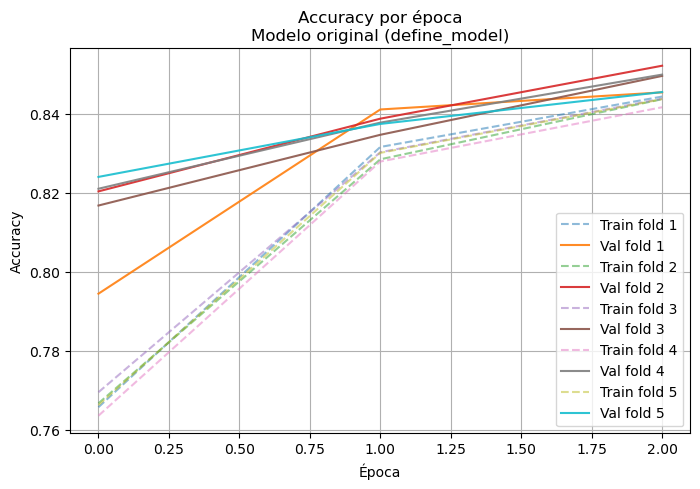

Modelo Tarea 2


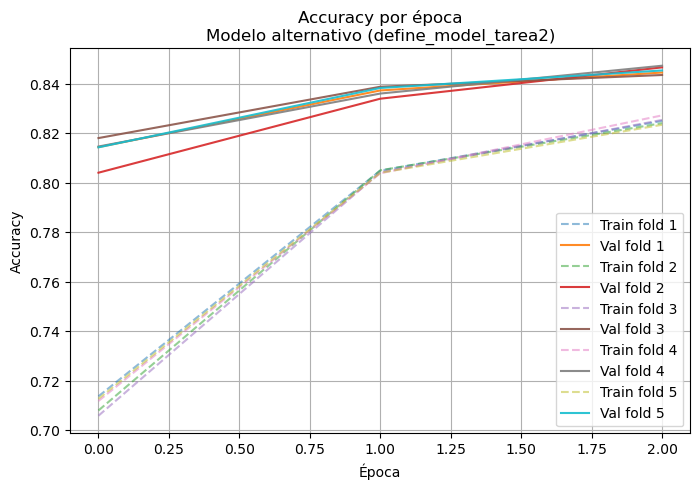

In [17]:
print("Modelo original")
graficar_resumen(histories_base, titulo="Modelo original (define_model)")

print("Modelo Tarea 2")
graficar_resumen(histories_t2, titulo="Modelo alternativo (define_model_tarea2)")


### Interpretación de las curvas de accuracy por época

En las figuras se muestran las curvas de `accuracy` de entrenamiento (líneas punteadas)
y validación (líneas continuas) para cada uno de los 5 folds de la validación cruzada.

**Conclusión visual**

Las gráficas confirman lo que mostraron las métricas numéricas:

- Ambos modelos aprenden de forma estable y no muestran un sobreajuste evidente en
  solo 3 épocas.
- El modelo original alcanza un accuracy promedio de validación ligeramente mayor.
- El modelo alternativo, con más capacidad y Dropout, consigue curvas muy consistentes
  entre folds y una variabilidad más baja, aunque con un accuracy promedio algo menor.

En conjunto, las diferencias son pequeñas; visualmente, ambos modelos se comportan de
manera similar, con un ligero trade-off entre precisión promedio (mejor en el modelo
original) y estabilidad de los resultados (mejor en el modelo alternativo).


## Stacking con red neuronal como meta-modelo

Además de comparar arquitecturas de redes densas, construimos un esquema de
**stacking**:

1. Definimos varios **modelos base** clásicos (Regresión Logística, KNN,
   Árbol de decisión, SVM) que se entrenan sobre las imágenes de Fashion-MNIST.
2. Para un subconjunto de validación, cada modelo base genera probabilidades por
   clase (`predict_proba`).
3. Concatenamos esas probabilidades y las usamos como **nuevas features**.
4. Entrenamos una **red neuronal pequeña** sobre estas nuevas features.
   Esta red es el **meta-modelo**, cuya entrada son las predicciones de los
   modelos base y cuya salida es la clase final (10 categorías).


In [19]:
from sklearn.model_selection import train_test_split

# 1) Aplanar imágenes para los modelos de sklearn

# trainX: (n, 28, 28, 1) -> (n, 784)
X_flat = trainX.reshape(trainX.shape[0], -1)
X_test_flat = testX.reshape(testX.shape[0], -1)

# y en enteros (sklearn NO usa one-hot)
y_int = np.argmax(trainY, axis=1)
y_test_int = np.argmax(testY, axis=1)

# 2) Separar base_train y meta_train
#    - Base_train: para entrenar los modelos base
#    - Meta_train: para generar las features que usará la red meta

X_base, X_meta, y_base_int, y_meta_int, y_base_oh, y_meta_oh = train_test_split(
    X_flat, y_int, trainY,           # X, y_int, y_onehot
    test_size=0.2,                   # 80% base, 20% meta
    random_state=42,
    stratify=y_int                   # estratificado por clase
)

print("X_base:", X_base.shape)
print("X_meta:", X_meta.shape)


X_base: (48000, 784)
X_meta: (12000, 784)


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Definimos varios modelos base
base_models = {
    "logistica": LogisticRegression(max_iter=1000, n_jobs=-1),
    "knn": KNeighborsClassifier(n_neighbors=5),
    "arbol": DecisionTreeClassifier(max_depth=20),
    "svm": SVC(kernel="rbf", C=5, probability=True)  # probability=True para usar predict_proba
}

# Entrenamos cada modelo sobre X_base
for name, model in base_models.items():
    print(f"Entrenando modelo base: {name}")
    model.fit(X_base, y_base_int)


Entrenando modelo base: logistica


/Users/andrespadronquintana/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Entrenando modelo base: knn
Entrenando modelo base: arbol
Entrenando modelo base: svm


In [21]:
# -------------------------------------------------------------------
# 3) Generar las features meta: concatenar predict_proba de cada modelo
# -------------------------------------------------------------------
n_meta = X_meta.shape[0]
n_clases = trainY.shape[1]          # 10
n_modelos = len(base_models)

# Lista para ir guardando las matrices (n_meta, n_clases)
meta_features_list = []

for name, model in base_models.items():
    print(f"Obteniendo predicciones de {name} sobre X_meta...")
    proba = model.predict_proba(X_meta)   # shape: (n_meta, 10)
    meta_features_list.append(proba)

# Concatenamos a lo largo de las columnas:
# resultado: (n_meta, n_clases * n_modelos)
meta_X = np.concatenate(meta_features_list, axis=1)
meta_y = y_meta_oh   # usamos one-hot para la red

print("Shape de meta_X:", meta_X.shape)   # (n_meta, 10 * nº modelos)
print("Shape de meta_y:", meta_y.shape)


Obteniendo predicciones de logistica sobre X_meta...
Obteniendo predicciones de knn sobre X_meta...
Obteniendo predicciones de arbol sobre X_meta...
Obteniendo predicciones de svm sobre X_meta...
Shape de meta_X: (12000, 40)
Shape de meta_y: (12000, 10)


In [22]:
# Definir la red neuronal

def define_meta_nn(input_dim, n_classes=10):
    """
    Red neuronal que actúa como meta-modelo.
    Entrada: probabilidades concatenadas de los modelos base.
    """
    inp = Input(shape=(input_dim,))
    
    # Capa oculta 1
    x = Dense(64, activation="relu")(inp)
    # Capa oculta 2
    x = Dense(32, activation="relu")(x)
    
    # Capa de salida
    out = Dense(n_classes, activation="softmax")(x)
    
    meta_model = Model(inputs=inp, outputs=out)
    meta_model.compile(
        optimizer=SGD(learning_rate=0.01),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return meta_model

meta_model = define_meta_nn(input_dim=meta_X.shape[1])
meta_model.summary()


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,034 (19.66 KB)

 Trainable params: 5,034 (19.66 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Entrenar la red
history_meta = meta_model.fit(
    meta_X, meta_y,
    epochs=10,
    batch_size=64,
    validation_split=0.2,   # 20% de meta_X para validación interna del meta-modelo
    verbose=1
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4078 - loss: 2.1220 - val_accuracy: 0.7533 - val_loss: 1.9446
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8053 - loss: 1.7535 - val_accuracy: 0.8217 - val_loss: 1.5589
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8482 - loss: 1.3510 - val_accuracy: 0.8650 - val_loss: 1.1552
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8767 - loss: 0.9664 - val_accuracy: 0.8896 - val_loss: 0.8117
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8910 - loss: 0.6847 - val_accuracy: 0.8896 - val_loss: 0.6002
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8925 - loss: 0.5290 - val_accuracy: 0.8904 - val_loss: 0.4921
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8935 - loss: 0.4502 - val_accuracy: 0.8896 - val_loss: 0.4360
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8950 - loss: 0.4081 - val_accuracy: 0.

In [24]:
# Construir meta-features para el conjunto de prueba

test_features_list = []

for name, model in base_models.items():
    print(f"Predicciones de {name} sobre X_test...")
    proba_test = model.predict_proba(X_test_flat)  # (n_test, 10)
    test_features_list.append(proba_test)

meta_X_test = np.concatenate(test_features_list, axis=1)  # (n_test, 10 * n_modelos)

# -------------------------------------------------------------------
# 5) Evaluar el meta-modelo sobre meta_X_test y testY
# -------------------------------------------------------------------
test_loss, test_acc = meta_model.evaluate(meta_X_test, testY, verbose=0)
print(f"Accuracy en test del stacking con red neuronal meta: {test_acc*100:.2f}%")


Predicciones de logistica sobre X_test...
Predicciones de knn sobre X_test...
Predicciones de arbol sobre X_test...
Predicciones de svm sobre X_test...
Accuracy en test del stacking con red neuronal meta: 88.56%


### Stacking con modelos clásicos y red neuronal como meta-modelo

Además de comparar dos arquitecturas de redes densas sobre las imágenes originales,
se construyó un esquema de **stacking** donde una red neuronal actúa como
**meta-modelo** y combina las salidas de varios clasificadores clásicos.

El procedimiento fue el siguiente:

1. **Preparación de datos**

   - Las imágenes de Fashion-MNIST se aplanaron de tamaño \(28 \times 28\) a vectores de
     dimensión 784 para poder usarlas en modelos de `scikit-learn`.
   - Las etiquetas se mantuvieron en formato entero (0–9) para los modelos base y en
     formato *one-hot* para la red meta.
   - El conjunto de entrenamiento se dividió en dos partes:
     - `Base_train` (80 %): para entrenar los modelos base.
     - `Meta_train` (20 %): para construir las variables de entrada del meta-modelo.

2. **Modelos base**

   Se entrenaron cuatro clasificadores distintos sobre `Base_train`:

   - Regresión Logística (`LogisticRegression`),
   - K-vecinos más cercanos (`KNeighborsClassifier`),
   - Árbol de decisión (`DecisionTreeClassifier`),
   - SVM con kernel RBF (`SVC` con `probability=True`).

   Cada modelo produjo probabilidades de clase `predict_proba` sobre `Meta_train`.
   Como hay 10 clases, cada modelo genera una matriz de tamaño
   \((n_{\text{meta}}, 10)\). Al concatenar las salidas de los cuatro modelos,
   se obtuvo una matriz de características de dimensión:

  $$ 
   \mathbb{R}^{12000 \times 40}
  $$

   (12,000 observaciones y 40 columnas = 4 modelos × 10 clases).

3. **Red neuronal meta-modelo**

   Sobre `meta_X` se entrenó una red neuronal densa que actúa como
   **meta-modelo**:

   - Capa de entrada: 40 nodos (probabilidades concatenadas).
   - Capa oculta 1: 64 neuronas, activación ReLU.
   - Capa oculta 2: 32 neuronas, activación ReLU.
   - Capa de salida: 10 neuronas, activación softmax.
   - Optimizador: SGD con `learning_rate = 0.01`.
   - Pérdida: `categorical_crossentropy`.
   - Total de parámetros entrenables: **5,034**.

   Esta red se entrenó con 10 épocas y `validation_split = 0.2` sobre `Meta_train`.

4. **Evaluación en el conjunto de prueba**

   Para evaluar el stacking, se repitió el proceso de generación de características
   sobre el **conjunto de prueba**:

   - Cada modelo base calculó `predict_proba(X_test)`, produciendo de nuevo cuatro
     matrices \((n_{\text{test}}, 10)\), que se concatenaron en una matriz
     \(\text{meta\_X\_test} \in \mathbb{R}^{10000 \times 40}\).
   - El meta-modelo de red neuronal se evaluó sobre estas nuevas características.

   El resultado obtenido fue:

   - **Accuracy en test del stacking con red neuronal meta:** **88.56 %**

   Este desempeño es claramente superior al alcanzado por las redes densas entrenadas
   directamente sobre las imágenes (alrededor de 84.5–84.9 % con validación cruzada),
   lo que muestra que el stacking está aprovechando información complementaria de los
   distintos modelos base.

En resumen, el esquema de stacking permite usar una **red neuronal como última instancia**
que integra las probabilidades generadas por varios modelos clásicos
(Regresión logística, KNN, Árbol, SVM) y logra una mejora sustancial en el accuracy
de clasificación sobre Fashion-MNIST.
